# EMC Conducted Emissions Test <a class="title_class" id="title_1"></a>

<img src  = "Test3/figs/first.png">

## Table of contents
 
   * [Test setup ](#title_2)
   * [EMI Filter Schematic Reminder](#title_3)
   * [Common-mode and Differential-mode Separation](#title_4)
   * [HVP HVN, Vin 380V, Before using input filter](#title_5)
     * [HVP & HVN Q-Peak](#title_6)
     * [HVP Q-Peak, Peak and AVG](#title_7)
     * [HVN Q-Peak, Peak and AVG](#title_8)
   * [Common Mode Choke (CMC) impact](#title_9)
   * [Adding film capacitors and snubber](#title_10)
   * [Adding ceramic y-capacitors](#title_11)
   * [Try differential snubber 220nF and 2.4 ohm](#title_12)
   * [Try common mode snubber 4.7nF and 360 ohm](#title_13)
   * [EMC measurement with and without EMI filter](#title_14)
     * [HVP and HVN Q-Peak after using the EMI filter](#title_15)
     * [HVP Q-Peak, Peak and AVG, after using EMI filter](#title_16)
     * [HVN Q-Peak, Peak and AVG, after using EMI filter](#title_17)
     * [HVP Q-PEAK before vs after using EMI filter ](#title_18)
   * [Annexes ](#title_19)
     * [Main power supply noise](#title_20)
     * [FlyBack noise](#title_21)
     * [EMI impact of Gate driver resistor (Rg) ](#title_22)
     * [Common-mode and Differential-mode Separation (Math)](#title_23)

## Introducition

The goal of this test is to see the impact of the EMI filter on the conducted emissions of the DC‑DC converter.  
Since we don't have a professional EMI receiver, the idea is to use an isolated oscilloscope powered by a 12V battery, and to use a Python package that we already developed and validated to emulate an EMC receiver.   <br>  
For more details about this EMI emulator, you can see the <a href="https://pypi.org/project/emi-receiver/PyPi"> PyPi page </a> or the <a href = "<https://github.com/bouz1/PypiContributions/tree/main/emi-receiverGitHub"> github page </a> of this project.   <br>  
The available oscilloscope for this test is the Tektronix TDS3034B, which has a limited memory depth of 10k points.  
To have a longer signal, the idea is to perform many acquisitions using a Python script (for more details see **EMI\_saving\_1CH.py**). We chose a horizontal resolution of 20 µs/div, and with 10k points the sampling time is 20 ns (50 MS/s), giving a recorded duration of 200 µs per shot. We will perform 50 shots each time, resulting in a total measurement time of 10 ms.   <br>  
No trigger is configured—each shot is taken randomly to avoid any bias in the measurement.   <br>  
After each measurement, we use the Python EMI‑receiver emulator to preprocess the signal and estimate AVG, PEAK, and QPEAK.

**Limitations of this test**   <br>

*   No EMI receiver, but the oscilloscope coupled with Python code gives satisfying results.
*   No conventional setup, but using a metallic ground plane and a 5 µH LISN approximates the standard setup.
*   This test is not intended for absolute measurements (like comparing the results to standard limits). It is only intended to compare the “before” and “after” of each modification. Absolute measurements may not be very accurate, but we hope that the delta will be accurate enough.

In [1]:
import os
# change folder for notebook
#os.chdir(r"C:\Users\a037702\NotSynchronized\git\Design_of_1200W_LLC_DCDC\05_validations\08_EMI")
#print(os.getcwd())

In [2]:
# LIBS 
import matplotlib.pyplot as plt 
import numpy as np 
# %pip install emi-receiver
from emi_receiver import receiver
import ast
from handcalcs import  render
from handcalcs import  *
import handcalcs
from localcode3 import *
fig_counter=1


import contextlib
import io
#######################################

# UTILS
def raw_to_volte(raw, dic):
    y_increment =  float(dic["y_increment"])
    y_origin =  float(dic["y_origin"])
    y_offset =  float(dic["y_offset"])
    voltage = (raw - y_offset) * y_increment + y_origin
    return voltage 
def path_to_signal(path):
    arr= np.load(path)
    yraw=arr.flatten() 
    with open(path.replace("_raw.npy","_seeting.txt")) as f:
        dic=f.read()
    # Convert string to dict
    dic = ast.literal_eval(dic)
    y=raw_to_volte(yraw, dic)
    y=y-y.mean()
    y=y/float(dic['SCALE'])
    Ts=float(dic['x_increment'])
    y = y -y.mean()
    return Ts, y


In [3]:
# CONFIGURATIONS
#help(handcalcs.set_option)
handcalcs.set_option("latex_block_start", "$")
handcalcs.set_option("latex_block_end", "$")
handcalcs.set_option("math_environment_end", "aligned")
handcalcs.set_option("use_scientific_notation",True)

In [4]:
# Initialization 
bl= '#1520c0' # blue 
rd= '#C62828' # red
fig_counter=1

## Test setup  <a class="title_class" id="title_2"></a>

In [5]:

fig_counter=One_figure_with_captions(fig_counter, img1="setup.png"
                                     , caption1="Setup schematic",
                                     first_part_path="Test3/figs/", 
                                     width=19)

The setup is composed of a power supply (345V–405V, 800W) fixed to 380V as the nominal voltage, a LISN of two phases of 5 µH, the DCDC converter, a secondary load of 27 Ω, the oscilloscope, and its battery to ensure isolation.   <br>

*   The DCDC and the load are placed on top of an insulating polystyrene layer of around 2 cm. The output voltage is regulated to 42V. We chose a low voltage to avoid under‑resonance issues since the current software is not the final version. With this configuration, we will have around 70 W at the output, which is enough to observe the DCDC noise.
*   The DCDC is placed on top of two fans powered by its internal flyback, and it is grounded to the aluminum plane using two ground braids.
*   The LISN is also grounded to the aluminum plane using its ground braid.
*   The oscilloscope is isolated using several polystyrene layers to minimize the parasitic capacitance.
*   The load and all wires are placed in the top of the polystyrene layer to reduce the parasite capacitor with ground

In [6]:

fig_counter=One_figure_with_captions(fig_counter, img1="IMG_20260209_160925.jpg"
                                     , caption1="full setup",
                                     first_part_path="Test3/figs/", 
                                     width=19)

In [7]:

fig_counter=One_figure_with_captions(fig_counter, img1="IMG_20260209_160930.jpg"
                                     , caption1="full setup, load",
                                     first_part_path="Test3/figs/", 
                                     width=19)

In [8]:
fig_counter=One_figure_with_captions(fig_counter, img1="IMG_20260209_160939.jpg"
                                     , caption1="grounds of the dcdc and the LISN",
                                     first_part_path="Test3/figs/", 
                                     width=19)

In [9]:


fig_counter= show_figure_pair_with_captionsOLD(fig_counter, 
                                            img1="IMG_20260209_160946.jpg", 
                                            caption1="LISN and power supply", 
                                            img2="lisn.png",#"IMG_20260209_161101.jpg", 
                                            caption2="5µH LISN schematic", 
                                            first_part_path="Test3/figs/" )

## EMI Filter Schematic Reminder <a class="title_class" id="title_3"></a>

Below is a reminder of the proposed schematic of the EMI filter. 
<br>The snubber capacitor is changed from 2.2nF to 15nF.

In [10]:
fig_counter=One_figure_with_captions(fig_counter, img1="schematic1.png"
                                     , caption1="The main EMI filter schematic",
                                     first_part_path="Test3/figs/", 
                                     width=19)

Below the position of the 5 ceramic-y capacitors. 
<br>The ceramic capacitor used is 400VAC 102M 1NF (1nF) instead of 220pF as you can see below.

In [11]:
fig_counter=One_figure_with_captions(fig_counter, img1="schematic2.png"
                                     , caption1="Ceramic y-caps 1nF",
                                     first_part_path="Test3/figs/", 
                                     width=19)

## Common-mode and Differential-mode Separation <a class="title_class" id="title_4"></a>

In all tests, we try to separate the common‑mode noise from the differential‑mode noise. To do this, we use a magnetic core recovered from a failed Tektronix TCP1015 current probe. 
<br>We added five external turns to form a secondary winding, and this secondary is connected to the oscilloscope using its 50‑ohm internal termination.


In [12]:
fig_counter=One_figure_with_captions(fig_counter, img1="IMG_20260209_143837.jpg"
                                     , caption1="Magnetic core of TCP0150 (common mode)",
                                     first_part_path="Test3/figs/", 
                                     width=10)

fig_counter=One_figure_with_captions(fig_counter, img1="cm_diff.png"
                                     , caption1="Common mode and differential mode measurement method",
                                     first_part_path="Test3/figs/", 
                                     width=12)

In [13]:
path = "Test3/EMI_2026-02-09_16-01-54-195/CH2_raw.npy"
Ts, ycm = path_to_signal(path)

path = "Test3/EMI_2026-02-09_15-58-58-868/CH2_raw.npy"
Ts, ydm = path_to_signal(path)

In [14]:
Channel_Voltage=1
N_turns = 5
R_Terminal= 50

Below are the formulas used to convert the measured voltage into the estimated common‑mode and differential‑mode currents.

In [15]:
#%%tex
# Current trans 

#i_cm= ((Channel_Voltage/R_Terminal)*Nturns) 
#i_dm= ((Channel_Voltage/R_Terminal)*Nturns) /2


# it is an error 
# i must use small resistor like 1 ohm or less to charge the CT

$
\begin{aligned}
i_{cm} &= \left( \left( \frac{ \mathrm{Channel}_{Voltage} }{ R_{Terminal} } \right) \cdot \mathrm{Nturns} \right) 
\\[10pt]
i_{dm} &= \frac{ \left( \frac{ \mathrm{Channel}_{Voltage} }{ R_{Terminal} } \right) \cdot \mathrm{Nturns} }{ 2 }  
\end{aligned}
$

In [16]:
Nturns = 5
icm= ((ycm/50)*Nturns) 
idm= ((ydm/50)*Nturns) 
idm=idm/2

A zoom plot of both estimated currents

Text(0, 0.5, 'Current (mA)')

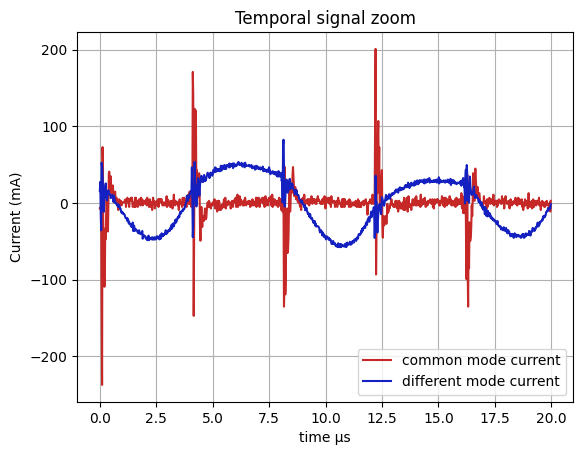

In [17]:
nnn=1000
t = np.arange(0,Ts*(nnn-1), Ts)
plt.plot(t*1e6, 1e3*icm[:nnn], label='common mode current', c=rd)
plt.plot(t*1e6, 1e3*idm[:nnn], label='different mode current', c=bl)

plt.grid()
plt.legend()
plt.title("Temporal signal zoom")
plt.xlabel("time µs")
plt.ylabel("Current (mA)")

In [18]:
# AVOID printing result of calculation like 
_="""
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
"""
with contextlib.redirect_stdout(io.StringIO()):
    freqs, peak, avg, qp = receiver(icm, 1/Ts, rbw=9000, band='B')

with contextlib.redirect_stdout(io.StringIO()):
    freqs2, peak2, avg2, qp2= receiver(idm,1/Ts, rbw=9000, band='B')


Below is the QPEAK estimation of both currents. We can see that the **differential‑mode current is predominant at low frequency (up to around 300 kHz)**, while the **common‑mode current becomes predominant above this frequency**.

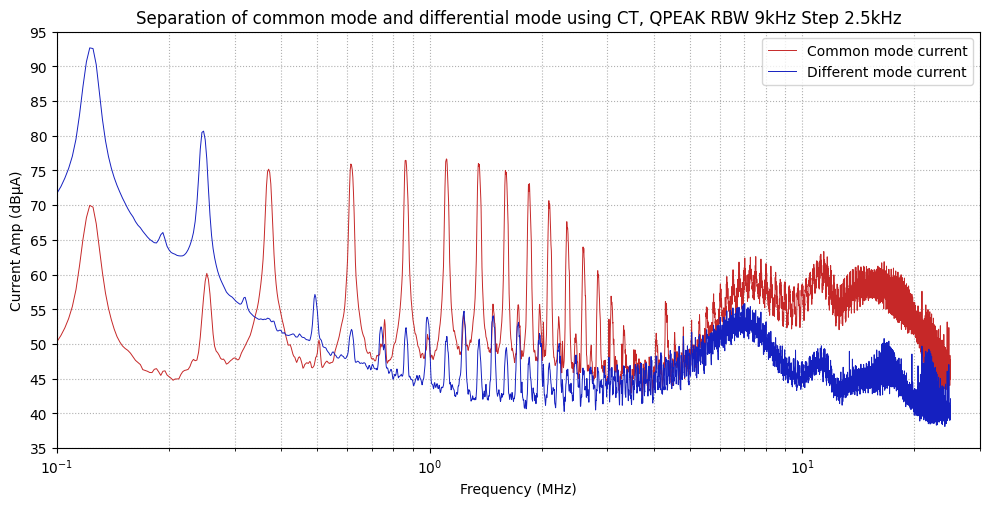

In [19]:
title="Separation of common mode and differential mode using CT, QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, qp, label='Common mode current', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='Different mode current', color=bl, linewidth=0.7)  

amax = 95
amin = 35

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

Below is an estimation of the reflected resistor using this setup. We can see that **2 Ω is a high value**, so using the oscilloscope’s **50 Ω input** as the load of the current transformer is a bad idea. Next time, we must add a **low external load**, such as **1 Ω**, so the reflected resistance on the primary will be only **40 mΩ**.


In [20]:
%%render 
# Current trans 
R_Terminal= 50 # Ω
N_turns= 5
R_reflected = R_Terminal/N_turns**2 # Ω

# it is an error 
# i must use small resistor like 1 ohm or less to charge the CT

<IPython.core.display.Latex object>

## HVP HVN, Vin 380V, Before using input filter <a class="title_class" id="title_5"></a>

In this test, we will measure the DCDC conducted emissions without a filter; this will be our reference to evaluate the filter's impact.


In [21]:
fig_counter=One_figure_with_captions(fig_counter, img1="IMG_20260209_162126.jpg"
                                     , caption1="PCB: Input filter zone",
                                     first_part_path="Test3/figs/", 
                                     width=10)

### HVP & HVN Q-Peak <a class="title_class" id="title_6"></a>

In [22]:
path = "Test3/EMI_2026-02-09_16-14-45-914/CH3_raw.npy"
Ts, hvp= path_to_signal(path)

path = "Test3/EMI_2026-02-09_16-15-55-875/CH3_raw.npy"
Ts, hvn = path_to_signal(path)

In [23]:
# AVOID printing result of calculation like 
_="""
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
"""
with contextlib.redirect_stdout(io.StringIO()):
    freqs, peak, avg, qp = receiver(hvp, 1/Ts, rbw=9000, band='B')

with contextlib.redirect_stdout(io.StringIO()):
    freqs2, peak2, avg2, qp2= receiver(hvn,1/Ts, rbw=9000, band='B')


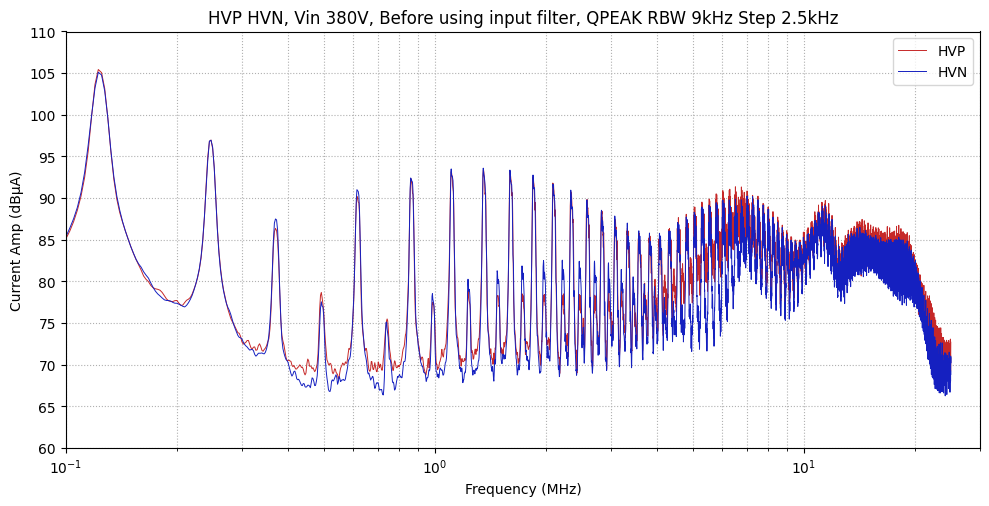

In [24]:
title="HVP HVN, Vin 380V, Before using input filter, QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, qp, label='HVP', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='HVN', color=bl, linewidth=0.7)  

amax = 110
amin = 60

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

### HVP Q-Peak, Peak and AVG <a class="title_class" id="title_7"></a>

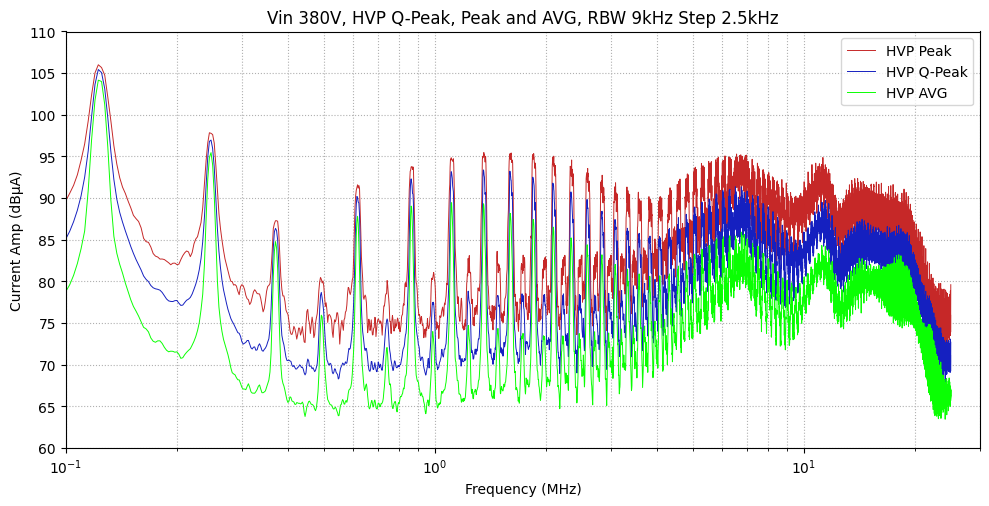

In [25]:
title="Vin 380V, HVP Q-Peak, Peak and AVG, RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, peak, label='HVP Peak', color=rd, linewidth=0.7)  
plt.semilogx(freqs*1e-6, qp, label='HVP Q-Peak', color=bl, linewidth=0.7)  
plt.semilogx(freqs*1e-6, avg, label='HVP AVG', color="#0AFF03", linewidth=0.7) 
amax = 110
amin = 60

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

### HVN Q-Peak, Peak and AVG <a class="title_class" id="title_8"></a>

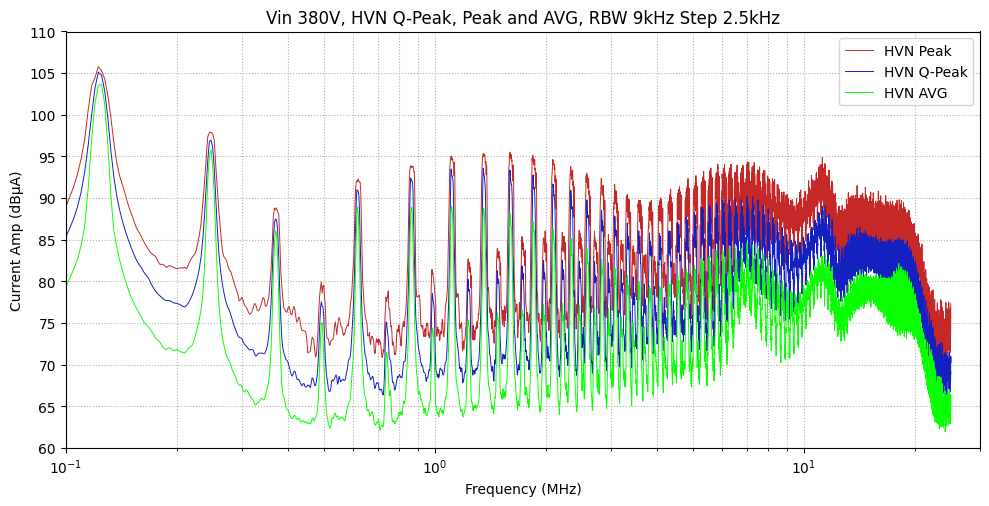

In [26]:
title="Vin 380V, HVN Q-Peak, Peak and AVG, RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs2*1e-6, peak2, label='HVN Peak', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='HVN Q-Peak', color=bl, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, avg2, label='HVN AVG', color="#0AFF03", linewidth=0.7) 
amax = 110
amin = 60

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

## Common Mode Choke (CMC) impact <a class="title_class" id="title_9"></a>

Start by adding the common‑mode choke (CMC) to the filter; no other elements are added. See the figures below.

In [27]:

fig_counter=show_figure_pair_with_captionsOLD(
    fig_counter, 
    img1="IMG_20260209_162126.jpg", 
    caption1="Before",
    img2="IMG_20260209_163705.jpg", 
    caption2="After", 
    first_part_path="Test3/figs/")

In [28]:
path = "Test3/EMI_2026-02-09_16-14-45-914/CH3_raw.npy"
Ts, hvp= path_to_signal(path)

path = "Test3/EMI_2026-02-09_16-28-39-062/CH3_raw.npy"
Ts, hvp_new = path_to_signal(path)

In [29]:
# AVOID printing result of calculation like 
_="""
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
"""
with contextlib.redirect_stdout(io.StringIO()):
    freqs, peak, avg, qp = receiver(hvp, 1/Ts, rbw=9000, band='B')

with contextlib.redirect_stdout(io.StringIO()):
    freqs2, peak2, avg2, qp2= receiver(hvp_new,1/Ts, rbw=9000, band='B')


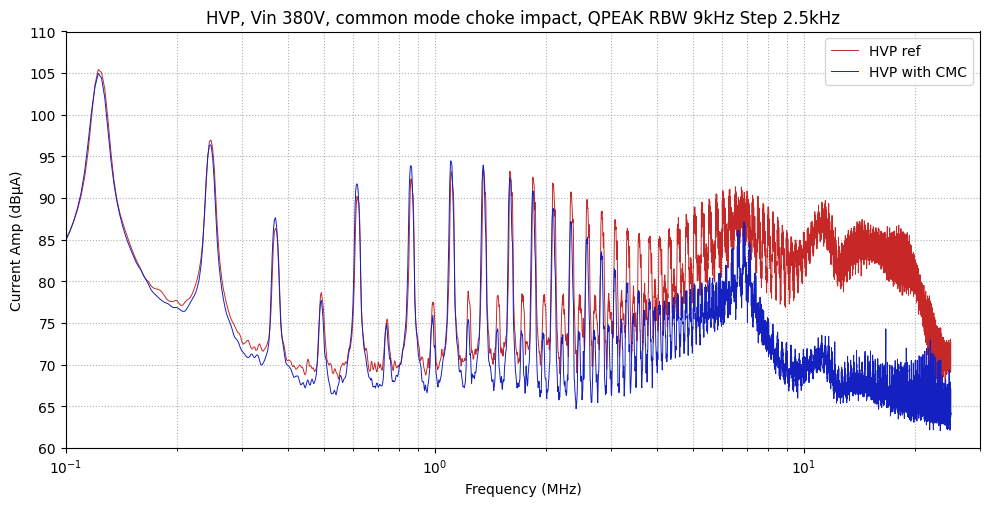

In [30]:
title="HVP, Vin 380V, common mode choke impact, QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, qp, label='HVP ref', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='HVP with CMC', color=bl, linewidth=0.7)  

amax = 110
amin = 60

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

The CMC has a visible impact in the high frequencies starting from 2 MHz, but only a slight impact below this frequency.

## Adding film capacitors and snubber <a class="title_class" id="title_10"></a>

In this step, we will add another film capacitor and the differential snubber (15 nF + 27 Ω).

In [31]:
 
fig_counter=show_figure_pair_with_captionsOLD(
    fig_counter, 
    img1="IMG_20260209_163705.jpg", 
    caption1="Before",
    img2="IMG_20260209_172848.jpg", 
    caption2="After", 
    first_part_path="Test3/figs/")

In [32]:

path = "Test3/EMI_2026-02-09_16-28-39-062/CH3_raw.npy"
Ts, hvp= path_to_signal(path)

path = "Test3/EMI_2026-02-09_18-05-30-391/CH3_raw.npy"
Ts, hvp_new = path_to_signal(path)

In [33]:
# AVOID printing result of calculation like 
_="""
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
"""
with contextlib.redirect_stdout(io.StringIO()):
    freqs, peak, avg, qp = receiver(hvp, 1/Ts, rbw=9000, band='B')

with contextlib.redirect_stdout(io.StringIO()):
    freqs2, peak2, avg2, qp2= receiver(hvp_new,1/Ts, rbw=9000, band='B')


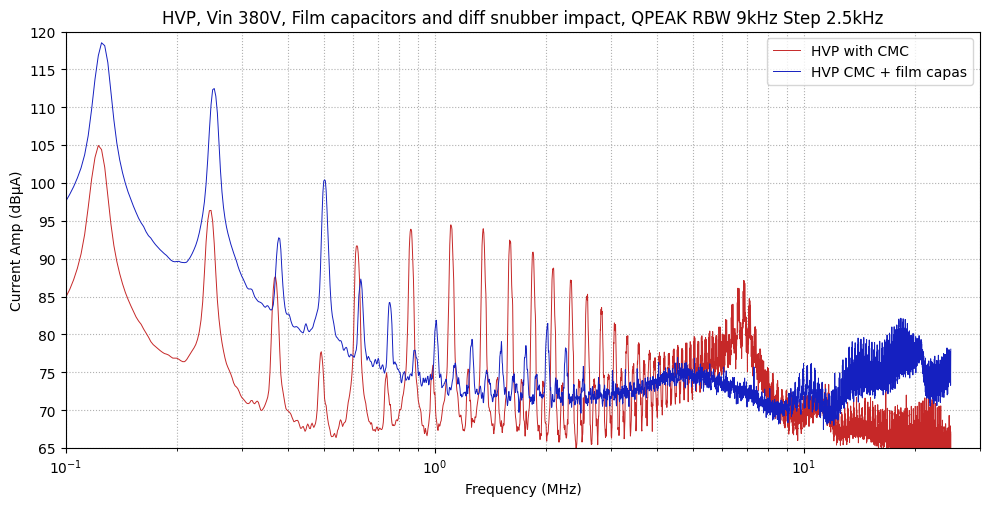

In [34]:
title="HVP, Vin 380V, Film capacitors and diff snubber impact, QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, qp, label='HVP with CMC', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='HVP CMC + film capas', color=bl, linewidth=0.7)  

amax = 120
amin = 65

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

The film capacitors (common‑mode and differential‑mode) help the filter at high frequencies, starting from around 600 kHz, but they have a negative impact at low frequencies.  

We must analyze by simulation whether there is a resonance with the LISN and the wiring impedance.


## Adding ceramic y-capacitors <a class="title_class" id="title_11"></a>

Since all control circuits are referenced to HVN, the five ceramic Y‑capacitors connect this potential to ground at four different points, and an additional ceramic capacitor connects HVP to ground

In [35]:
fig_counter=One_figure_with_captions(fig_counter, img1="IMG_20260209_181748.jpg"
                                     , caption1="The Y-ceramic capacitors are circled in red",
                                     first_part_path="Test3/figs/", 
                                     width=15)

In [36]:
path = "Test3/EMI_2026-02-09_18-05-30-391/CH3_raw.npy"
Ts, hvp= path_to_signal(path)


path = "Test3/EMI_2026-02-09_18-19-20-917/CH3_raw.npy"
Ts, hvp_new = path_to_signal(path)

In [37]:
# AVOID printing result of calculation like 
_="""
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
"""
with contextlib.redirect_stdout(io.StringIO()):
    freqs, peak, avg, qp = receiver(hvp, 1/Ts, rbw=9000, band='B')

with contextlib.redirect_stdout(io.StringIO()):
    freqs2, peak2, avg2, qp2= receiver(hvp_new,1/Ts, rbw=9000, band='B')


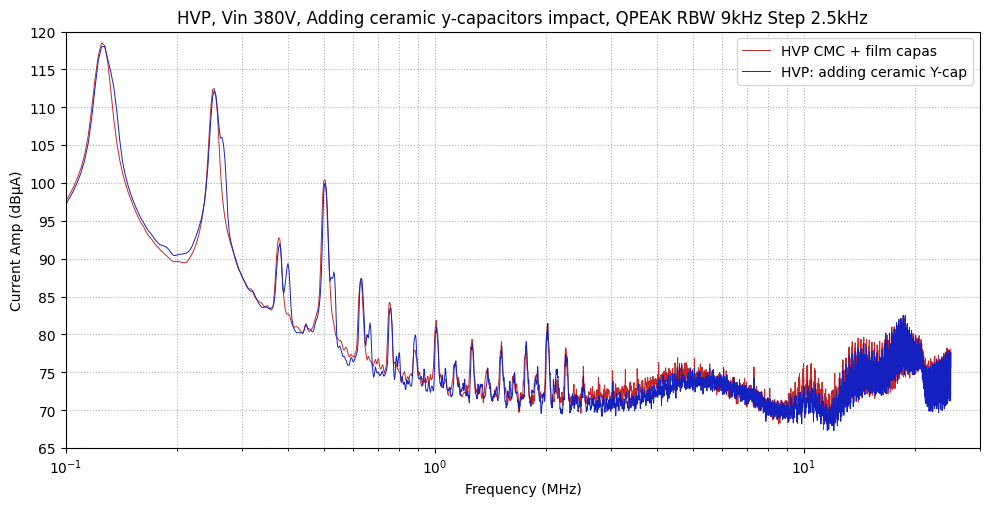

In [38]:
title="HVP, Vin 380V, Adding ceramic y-capacitors impact, QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, qp, label='HVP CMC + film capas', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='HVP: adding ceramic Y-cap', color=bl, linewidth=0.7)  

amax = 120
amin = 65

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

We observe slight improvements in the high‑frequency range (from around 2 MHz), but the effect is not very significant. We expect these capacitors to have more impact at higher frequencies.

## Try differential snubber 220nF and 2.4 ohm <a class="title_class" id="title_12"></a>

To investigate the performance degradation observed after adding the film capacitor, we added this differential snubber on the noise side to check whether it provides any low‑frequency damping.

In [39]:
fig_counter=One_figure_with_captions(fig_counter, img1="IMG_20260209_213036.jpg"
                                     , caption1="The prototype of a differential-mode snubber (0.22 µF & 2.4 Ω) is circled in red",
                                     first_part_path="Test3/figs/", 
                                     width=18)

In [40]:
path = "Test3/EMI_2026-02-09_18-19-20-917/CH3_raw.npy"
Ts, hvp= path_to_signal(path)


path = "Test3/EMI_2026-02-10_10-22-44-960/CH3_raw.npy"
Ts, hvp_new = path_to_signal(path)

In [41]:
# AVOID printing result of calculation like 
_="""
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
"""
with contextlib.redirect_stdout(io.StringIO()):
    freqs, peak, avg, qp = receiver(hvp, 1/Ts, rbw=9000, band='B')

with contextlib.redirect_stdout(io.StringIO()):
    freqs2, peak2, avg2, qp2= receiver(hvp_new,1/Ts, rbw=9000, band='B')


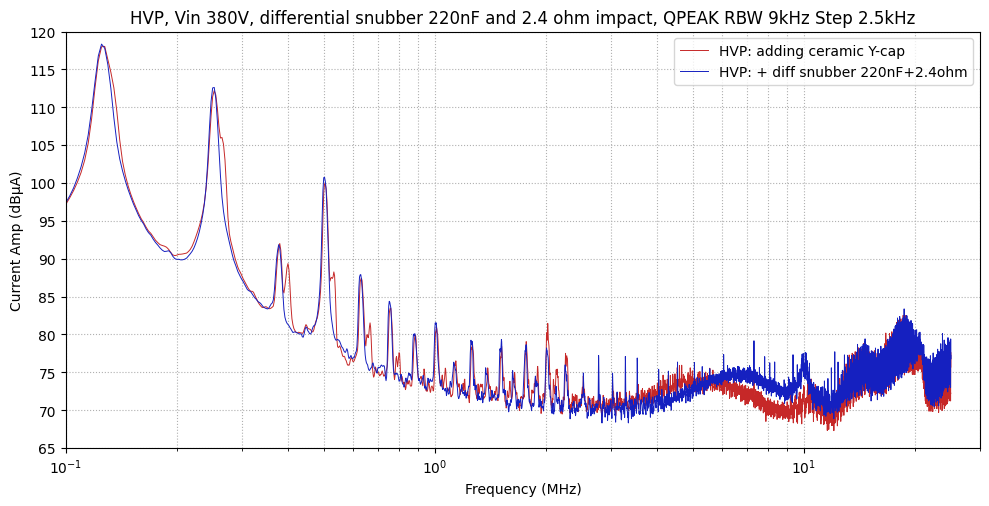

In [42]:
title="HVP, Vin 380V, differential snubber 220nF and 2.4 ohm impact, QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, qp, label='HVP: adding ceramic Y-cap', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='HVP: + diff snubber 220nF+2.4ohm', color=bl, linewidth=0.7)  

amax = 120
amin = 65

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

There is almost no improvement, particularly in the low‑frequency range. Only a slight effect is visible between 2 MHz and 10 MHz, suggesting that the issue is likely not caused by a differential‑mode resonance

## Try common mode snubber 4.7nF and 360 ohm <a class="title_class" id="title_13"></a>

Based on the differential snubber results, we now add the common‑mode snubber to determine whether the issue originates from a common‑mode resonance.

In [43]:
fig_counter=One_figure_with_captions(fig_counter, img1="IMG_20260210_105514.jpg"
                                     , caption1="The prototype of a common-mode snubber (4.7 nF & 360 Ω) is circled in red",
                                     first_part_path="Test3/figs/", 
                                     width=18)

In [44]:
path = "Test3/EMI_2026-02-09_18-19-20-917/CH3_raw.npy"
Ts, hvp= path_to_signal(path)


path = "Test3/EMI_2026-02-10_10-50-50-273/CH3_raw.npy"
Ts, hvp_new = path_to_signal(path)

In [45]:
# AVOID printing result of calculation like 
_="""
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
"""
with contextlib.redirect_stdout(io.StringIO()):
    freqs, peak, avg, qp = receiver(hvp, 1/Ts, rbw=9000, band='B')

with contextlib.redirect_stdout(io.StringIO()):
    freqs2, peak2, avg2, qp2= receiver(hvp_new,1/Ts, rbw=9000, band='B')


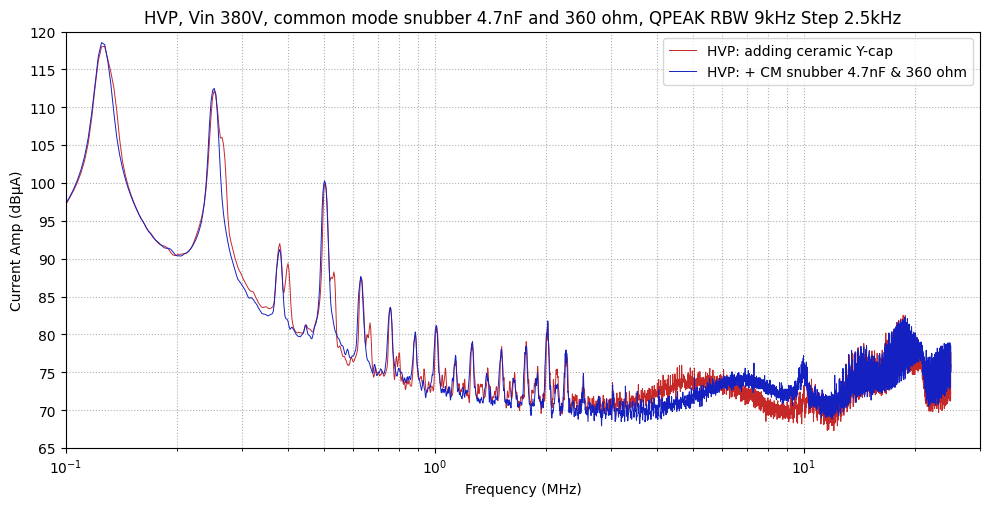

In [46]:
title="HVP, Vin 380V, common mode snubber 4.7nF and 360 ohm, QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, qp, label='HVP: adding ceramic Y-cap', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='HVP: + CM snubber 4.7nF & 360 ohm', color=bl, linewidth=0.7)  

amax = 120
amin = 65

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

The behaviour is almost identical to the differential snubber. Further, more detailed investigation is required to understand the impact of the film capacitor at low frequencies.

## EMC measurement with and without EMI filter <a class="title_class" id="title_14"></a>

In this section, we simply compare the system performance before and after adding the EMI filter. All prototype snubbers have been removed, and only the original EMI filter configuration is retained.

### HVP and HVN Q-Peak after using the EMI filter <a class="title_class" id="title_15"></a>

In [47]:
"""
ADD small capa 1nF x 5 
HVP 
EMI_2026-02-09_18-19-20-917
HVN
EMI_2026-02-09_18-20-26-964


OTHER TEST 

HVP
EMI_2026-02-10_11-34-04-039

HVN
EMI_2026-02-10_11-35-05-465
"""

path = "Test3/EMI_2026-02-09_18-19-20-917/CH3_raw.npy"
Ts, hvp= path_to_signal(path)


path = "Test3/EMI_2026-02-09_18-20-26-964/CH3_raw.npy"
Ts, hvn= path_to_signal(path)


_='''
path = "Test3/EMI_2026-02-10_11-34-04-039/CH3_raw.npy"
Ts, hvp= path_to_signal(path)


path = "Test3/EMI_2026-02-10_11-35-05-465/CH3_raw.npy"
Ts, hvn= path_to_signal(path)
'''

In [48]:
# AVOID printing result of calculation like 
_="""
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
"""
with contextlib.redirect_stdout(io.StringIO()):
    freqs, peak, avg, qp = receiver(hvp, 1/Ts, rbw=9000, band='B')

with contextlib.redirect_stdout(io.StringIO()):
    freqs2, peak2, avg2, qp2= receiver(hvn,1/Ts, rbw=9000, band='B')


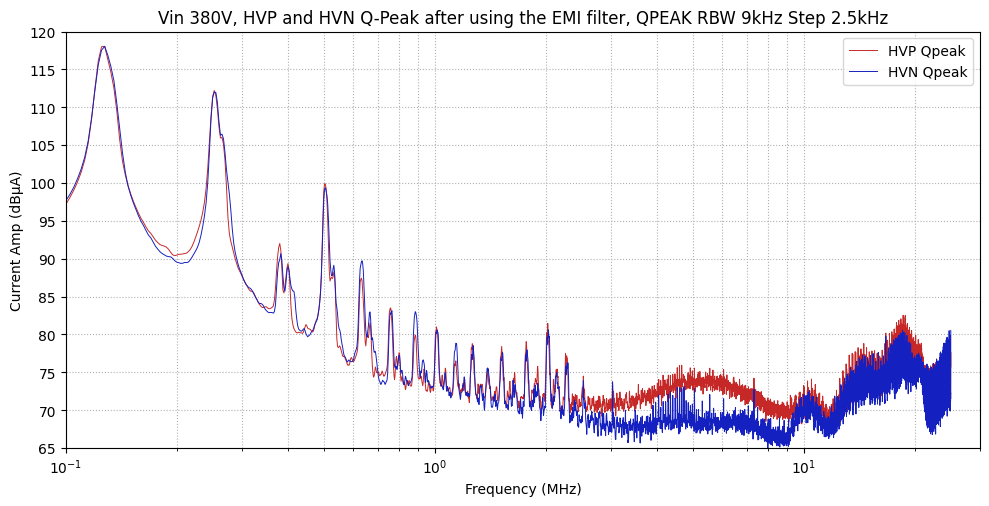

In [49]:
title="Vin 380V, HVP and HVN Q-Peak after using the EMI filter, QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, qp, label='HVP Qpeak', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='HVN Qpeak', color=bl, linewidth=0.7)  

amax = 120
amin = 65

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

HVP and HVN show nearly identical behaviour, with a slight difference on HVP between 2 MHz and 20 MHz. This may be due to the asymmetry between the two HV poles: HVN serves as the control‑circuit reference, while HVP ends at the drain of the high‑side primary MOSFET.

### HVP Q-Peak, Peak and AVG, after using EMI filter <a class="title_class" id="title_16"></a>

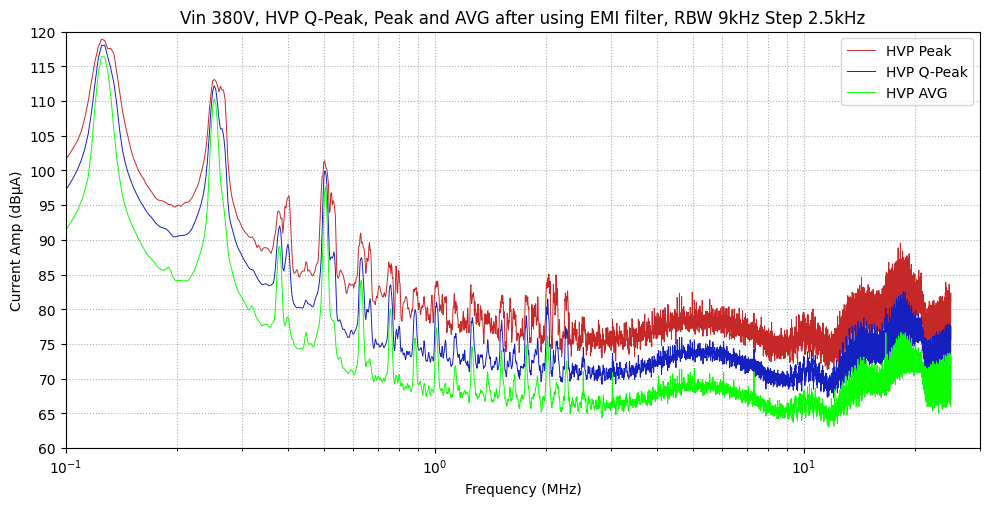

In [50]:
title="Vin 380V, HVP Q-Peak, Peak and AVG after using EMI filter, RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, peak, label='HVP Peak', color=rd, linewidth=0.7)  
plt.semilogx(freqs*1e-6, qp, label='HVP Q-Peak', color=bl, linewidth=0.7)  
plt.semilogx(freqs*1e-6, avg, label='HVP AVG', color="#0AFF03", linewidth=0.7) 
amax = 120
amin = 60

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

### HVN Q-Peak, Peak and AVG, after using EMI filter <a class="title_class" id="title_17"></a>

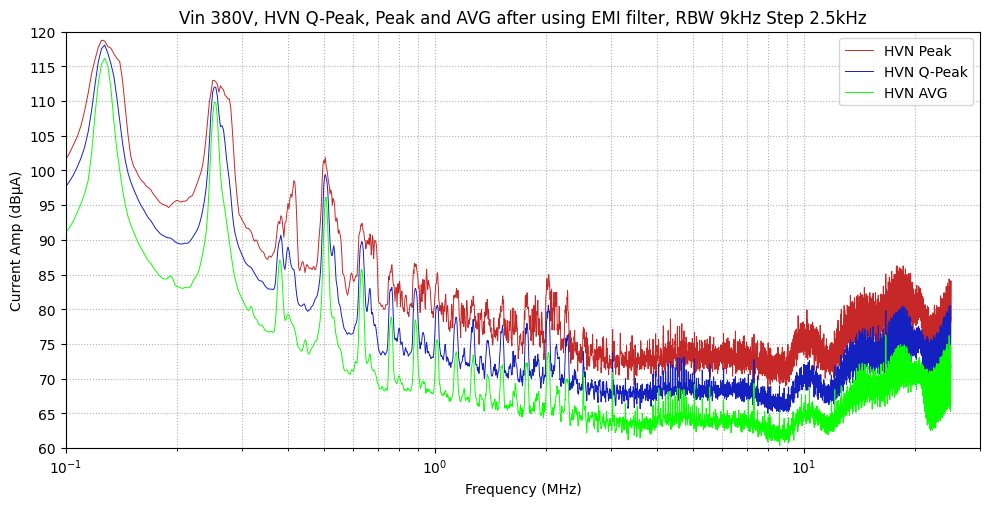

In [51]:
title="Vin 380V, HVN Q-Peak, Peak and AVG after using EMI filter, RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs2*1e-6, peak2, label='HVN Peak', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='HVN Q-Peak', color=bl, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, avg2, label='HVN AVG', color="#0AFF03", linewidth=0.7) 
amax = 120
amin = 60

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

### HVP Q-PEAK before vs after using EMI filter  <a class="title_class" id="title_18"></a>

In [52]:
path = "Test3/EMI_2026-02-09_16-14-45-914/CH3_raw.npy"
Ts, hvp= path_to_signal(path)


path = "Test3/EMI_2026-02-09_18-19-20-917/CH3_raw.npy"
Ts, hvp_new = path_to_signal(path)

In [53]:
# AVOID printing result of calculation like 
_="""
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
"""
with contextlib.redirect_stdout(io.StringIO()):
    freqs, peak, avg, qp = receiver(hvp, 1/Ts, rbw=9000, band='B')

with contextlib.redirect_stdout(io.StringIO()):
    freqs2, peak2, avg2, qp2= receiver(hvp_new,1/Ts, rbw=9000, band='B')


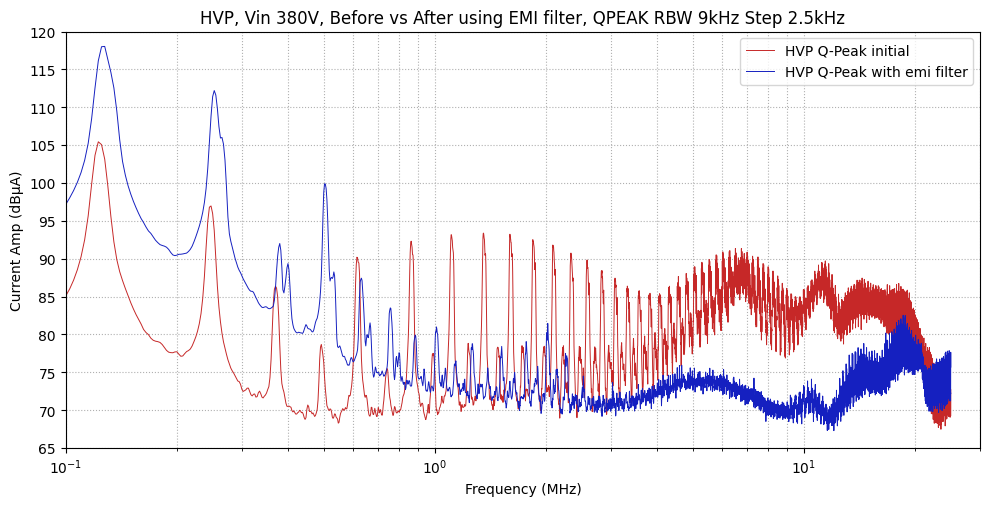

In [54]:
title="HVP, Vin 380V, Before vs After using EMI filter, QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, qp, label='HVP Q-Peak initial', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='HVP Q-Peak with emi filter', color=bl, linewidth=0.7)  

amax = 120
amin = 65

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

The EMI filter provides effective attenuation at high frequencies, beginning around 600 kHz, but it degrades performance at lower frequencies.<br>
This filter version is a solid starting point; however, additional simulations, analysis, and testing are required to improve the performance, particularly in the low‑frequency range.

## Annexes  <a class="title_class" id="title_19"></a>

In this section, you will find additional annex tests that help clarify and support the overall analysis of the conducted EMI measurements.

### Main power supply noise <a class="title_class" id="title_20"></a>

In this test, only the power supply is connected to the LISN, and all wires on the EUT side are removed.
    <br>
The objective is to evaluate how much noise from the power supply propagates through the LISN.

In [55]:
path = "Test3/EMI_2026-02-09_18-19-20-917/CH3_raw.npy"
Ts, hvp= path_to_signal(path)


path = "Test3/EMI_2026-02-10_11-02-27-557/CH3_raw.npy"
Ts, hvp_new = path_to_signal(path)

In [56]:
# AVOID printing result of calculation like 
_="""
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
"""
with contextlib.redirect_stdout(io.StringIO()):
    freqs, peak, avg, qp = receiver(hvp, 1/Ts, rbw=9000, band='B')

with contextlib.redirect_stdout(io.StringIO()):
    freqs2, peak2, avg2, qp2= receiver(hvp_new,1/Ts, rbw=9000, band='B')


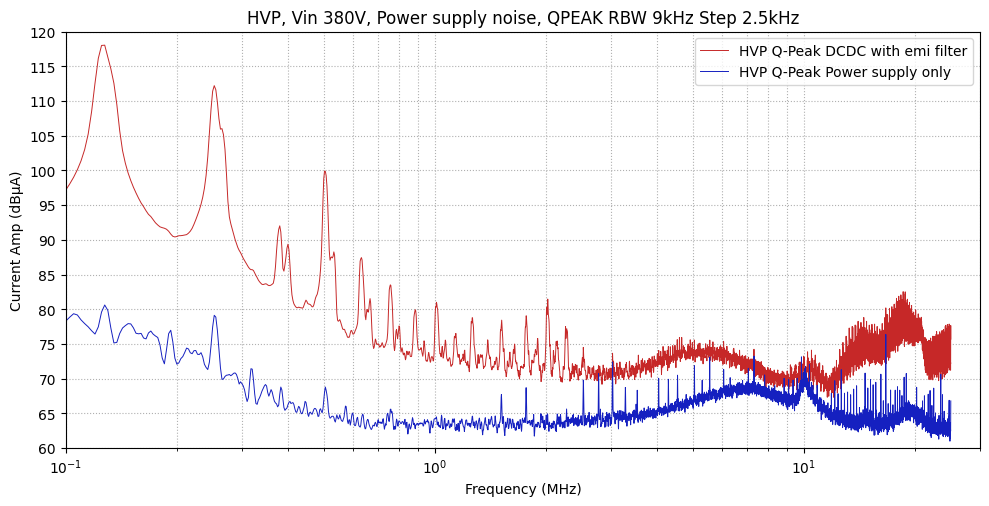

In [57]:
title="HVP, Vin 380V, Power supply noise, QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, qp, label='HVP Q-Peak DCDC with emi filter', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='HVP Q-Peak Power supply only', color=bl, linewidth=0.7)  

amax = 120
amin = 60

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

In this graph, we compare the HVP measurements with and without the DCDC connected. The power‑supply noise does not appear to dominate in the 150 kHz to 30 MHz range. 
<br>However, adding an output EMI filter between the power supply and the LISN could further reduce this noise and improve the overall result.

### FlyBack noise <a class="title_class" id="title_21"></a>

In this test, the gate‑driver jumper is opened to disable DCDC switching, allowing us to measure only the contribution of the flyback circuit.
<br> 
The fans remain powered and draw approximately 4 W from the flyback

In [58]:
path = "Test3/EMI_2026-02-09_18-19-20-917/CH3_raw.npy"
Ts, hvp= path_to_signal(path)


path = "Test3/EMI_2026-02-10_11-07-47-096/CH3_raw.npy"
Ts, hvp_new = path_to_signal(path)

In [59]:
# AVOID printing result of calculation like 
_="""
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
"""
with contextlib.redirect_stdout(io.StringIO()):
    freqs, peak, avg, qp = receiver(hvp, 1/Ts, rbw=9000, band='B')

with contextlib.redirect_stdout(io.StringIO()):
    freqs2, peak2, avg2, qp2= receiver(hvp_new,1/Ts, rbw=9000, band='B')


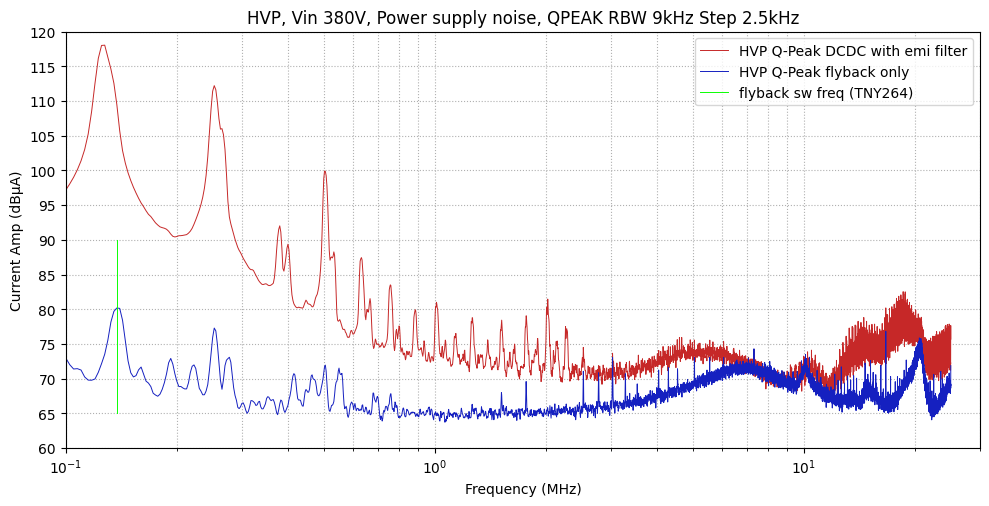

In [60]:
title="HVP, Vin 380V, Power supply noise, QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, qp, label='HVP Q-Peak DCDC with emi filter', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='HVP Q-Peak flyback only', color=bl, linewidth=0.7)  

ff=138
ff=ff/1000
#for i in range(1,5):
i=1
plt.plot([ff*i,ff*i], [65,90], label='flyback sw freq (TNY264)', color="#0AFF03", linewidth=0.7)  

amax = 120
amin = 60

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

Because the TNY264 controller operates at 132 kHz and includes ±8 kHz frequency jitter for spread‑spectrum noise reduction, we expected a noticeable decrease in EMI. <br>
However, the measured improvement is minimal. We confirmed that the flyback is active during this test, yet the results remain far below expectations, indicating that additional checks and deeper investigation are required.

### EMI impact of Gate driver resistor (Rg)  <a class="title_class" id="title_22"></a>

In this test, we evaluate the impact of switching speed using two different gate‑drive configurations:

*   **Configuration 1:**
    *   Primary gate‑drive resistance: parallel combination of 5.1 Ω and 3 Ω, giving an effective Rg of ***1.89 Ω***
    *   Secondary gate‑drive resistance: ***0 Ω***

*   **Configuration 2:**
    *   Primary gate‑drive resistance: ***10 Ω***
    *   Secondary gate‑drive resistance: ***3 Ω***

In [61]:
path = "Test3/EMI_2026-02-10_11-15-54-358/CH3_raw.npy"
Ts, hvp= path_to_signal(path)


path = "Test3/EMI_2026-02-10_11-18-31-655/CH3_raw.npy"
Ts, hvp_new = path_to_signal(path)

In [62]:
# AVOID printing result of calculation like 
_="""
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
"""
with contextlib.redirect_stdout(io.StringIO()):
    freqs, peak, avg, qp = receiver(hvp, 1/Ts, rbw=9000, band='B')

with contextlib.redirect_stdout(io.StringIO()):
    freqs2, peak2, avg2, qp2= receiver(hvp_new,1/Ts, rbw=9000, band='B')


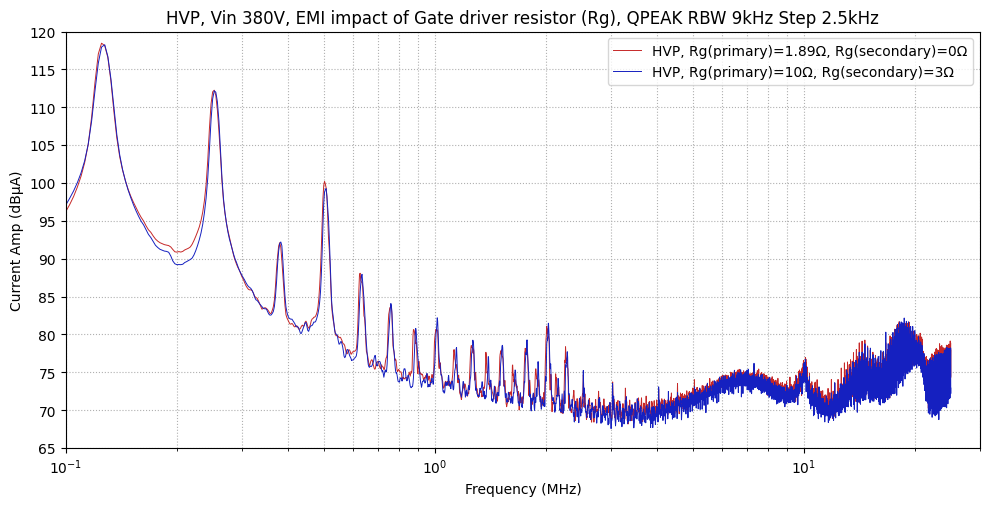

In [63]:
title="HVP, Vin 380V, EMI impact of Gate driver resistor (Rg), QPEAK RBW 9kHz Step 2.5kHz"
plt.figure(figsize=(10,5))




plt.semilogx(freqs*1e-6, qp, label='HVP, Rg(primary)=1.89Ω, Rg(secondary)=0Ω', color=rd, linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='HVP, Rg(primary)=10Ω, Rg(secondary)=3Ω', color=bl, linewidth=0.7)  

amax = 120
amin = 65

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

A slight improvement is observed in the high‑frequency range when using higher gate‑drive resistors (slower switching), but the effect remains limited. 
<br>The impact is smaller than expected, indicating that switching‑speed reduction alone may not be the dominant factor in this EMI behaviour.

### Common-mode and Differential-mode Separation (Math) <a class="title_class" id="title_23"></a>

In this test, we compare the CT‑based method for separating common‑mode and differential‑mode noise (discussed earlier) with a mathematical approach. In the mathematical method, we measure the voltage on each LISN channel and then compute the corresponding common‑mode and differential‑mode components.

A start‑synchronized acquisition with a stop button is used on the oscilloscope to eliminate timing delays between the two measurement channels.
The formulas used to calculate the common‑mode and differential‑mode currents are shown below.

In [64]:
path = "Test3/EMI_2026-02-09_16-01-54-195/CH3_raw.npy"
Ts, y1 = path_to_signal(path)
path = "Test3/EMI_2026-02-09_16-01-54-195/CH4_raw.npy"
Ts, y2 = path_to_signal(path)
icm = (y1+y2)/50


path = "Test3/EMI_2026-02-09_15-58-58-868/CH3_raw.npy"
Ts, y1 = path_to_signal(path)
path = "Test3/EMI_2026-02-09_15-58-58-868/CH4_raw.npy"
Ts, y2 = path_to_signal(path)
idm= (y1-y2)/(50*2)


In [65]:
from handcalcs import *

In [66]:
Channel_Voltage1 = Channel_Voltage2=1
R_Terminal=50

In [67]:
#%%tex
# Current trans 

#i_cm= (Channel_Voltage1+Channel_Voltage2)/R_Terminal
#i_dm= (Channel_Voltage1-Channel_Voltage2)/(R_Terminal*2)




$
\begin{aligned}
i_{cm} &= \frac{ \mathrm{Channel}_{Voltage1} + \mathrm{Channel}_{Voltage2} }{ R_{Terminal} } \\[10pt]
i_{dm} &= \frac{ \mathrm{Channel}_{Voltage1} - \mathrm{Channel}_{Voltage2} }{ R_{Terminal} \cdot 2 } 
\end{aligned}
$

In [68]:
# Receiver emulator 

import contextlib
import io
# AVOID printing result of calculation like 
_="""
--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------
"""
with contextlib.redirect_stdout(io.StringIO()):
    freqs, peak, avg, qp = receiver(icm, 1/Ts, rbw=9000, band='B')

with contextlib.redirect_stdout(io.StringIO()):
    freqs2, peak2, avg2, qp2= receiver(idm,1/Ts, rbw=9000, band='B')


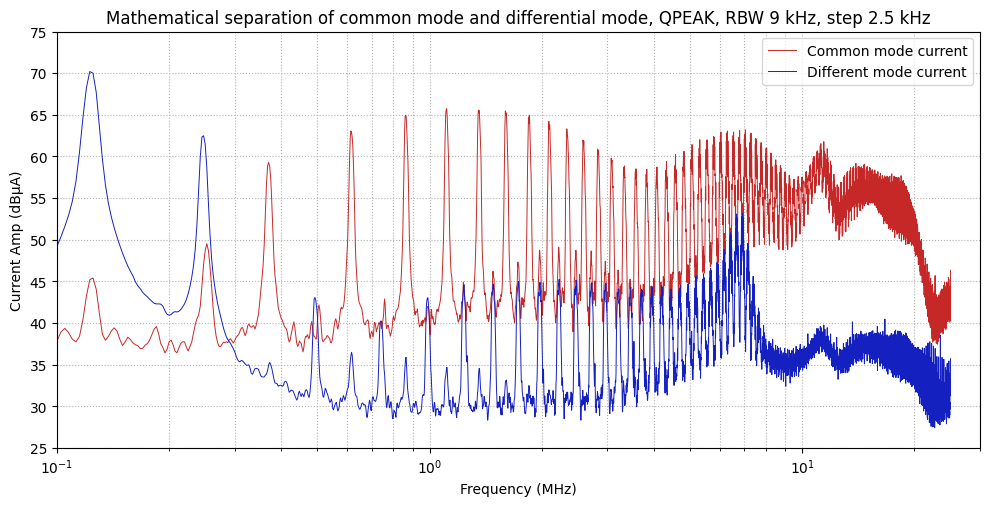

In [69]:
title="Mathematical separation of common mode and differential mode, QPEAK, RBW 9 kHz, step 2.5 kHz"
plt.figure(figsize=(10,5))

plt.semilogx(freqs*1e-6, qp, label='Common mode current', color='#C62828', linewidth=0.7)  
plt.semilogx(freqs2*1e-6, qp2, label='Different mode current', color='#1520c0', linewidth=0.7)  

amax = 75
amin = 25

plt.ylim(amin, amax)
plt.yticks(np.arange(amin, amax+1, 5))
plt.grid(True)

plt.grid(True, which='both', ls=':')
plt.xlabel('Frequency (MHz)')
plt.xlim([0.1, 30])
plt.ylabel('Current Amp (dBµA)')
plt.legend()
plt.tight_layout()
plt.title(title)
plt.show()

This method is not very robust. With the CT method, the sum and difference of the currents are performed physically, ensuring accurate separation of modes. In contrast, the mathematical approach relies on post‑sampling calculations, so even a small timing mismatch between oscilloscope channels can introduce significant errors—especially at high frequencies.

A small ADC‑related delay of about 10 ns is enough to shift two synchronised 50 MHz sine waves by up to 180°, meaning the computed difference can vary from 0 to 2×Amplitude. This illustrates how even tiny channel‑to‑channel timing errors can create large calculation errors at high frequencies.